In [50]:
# !pip install h5py
# !pip install umap-learn
#!pip install torch

In [51]:
import numpy as np
import pandas as pd
import h5py
import torch
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore
import umap.umap_ as umap


# Analysis of main dataset ("data/data_for_ml.h5")

In [52]:
fn="data/data_for_ml.h5"

In [53]:
#open the file in read mode
with h5py.File('data/data_for_ml.h5', 'r') as f:  
    keys = f.keys() #gives list of the names used in the file

    for key in keys:
        print(key)


DCIR
Dynamic_PsRP_1_1C
Dynamic_PsRP_1_C
Dynamic_PsRP_2_1C
Dynamic_PsRP_2_C
Static_HPPC
Static_PsRP_1
Static_PsRP_2_Chg
Static_PsRP_2_Dis
Static_Rapid


In [54]:
# loading specific data file 
data = pd.read_hdf(fn, key="Dynamic_PsRP_1_1C") # fn = file name and key= specific column we want to open
data

,soc,direction,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,voltage_7.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
0,0.011132,charge,6.799,7.092,7.119,7.142,7.163,6.624,6.608,6.599,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
1,0.172361,charge,7.966,8.200,8.209,8.216,8.222,7.760,7.749,7.742,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
2,0.333591,charge,8.126,8.341,8.350,8.357,8.363,7.936,7.925,7.917,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
3,0.494596,charge,8.288,8.411,8.411,8.410,8.411,8.098,8.089,8.082,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
4,0.644375,charge,8.387,8.408,8.409,8.410,8.410,8.192,8.183,8.177,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,0.474158,discharge,3.195,3.289,3.298,3.305,3.310,3.253,3.251,3.251,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4347,0.387823,discharge,3.178,3.276,3.287,3.295,3.300,3.243,3.241,3.240,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4348,0.301488,discharge,3.151,3.253,3.267,3.276,3.282,3.225,3.222,3.221,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4349,0.215153,discharge,3.103,3.213,3.232,3.244,3.253,3.195,3.192,3.191,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN


In [55]:
print(type(data));
print(data.dtypes);

<class 'pandas.core.frame.DataFrame'>
soc                                   float64
direction                              object
voltage_0.0s                          float64
voltage_1.0s                          float64
voltage_2.0s                          float64
                                       ...   
Post P/3 charge relaxation fit MSE    float64
Post C/2 charge relaxation fit MSE    float64
Post 1C charge relaxation fit MSE     float64
Thickness growth                      float64
Volume growth                         float64
Length: 264, dtype: object


In [56]:
# data type summery
dtype_counts = data.dtypes.value_counts()
print(dtype_counts)


float64    260
object       2
int64        2
Name: count, dtype: int64


In [57]:
# Get all columns that are object type
object_cols = data.select_dtypes(include='object').columns
print(object_cols.tolist())

['direction', 'cell_id']


In [58]:
# print(data['cell_id'])
# See all unique names for cell_id columns
unique_ids = data['cell_id'].unique()
print(unique_ids)

# Counting how many unique names there are
count_ids = data['cell_id'].nunique()
print(f"Number of unique cell_id values: {count_ids}")

# Want to see how many differnt types of cell_id there are
value_counts = data['cell_id'].value_counts()
print(value_counts)

['B_01' 'B_02' 'B_03' 'B_04' 'B_05' 'B_06' 'B_07' 'B_08' 'A_24' 'A_06'
 'A_10' 'A_11' 'A_15' 'A_21' 'A_22' 'A_02' 'A_03' 'A_04' 'A_20' 'A_05'
 'A_13' 'A_17' 'A_19' 'A_23' 'C_01' 'C_02' 'C_03' 'C_04' 'C_TX_04'
 'C_TX_05' 'C_TX_11' 'C_TX_13' 'C_TX_14' 'C_TX_32' 'C_TX_37' 'C_TX_43'
 'C_TX_48' 'C_TX_63' 'C_TX_66' 'C_TX_74' 'C_TX_64' 'C_NY_03' 'C_NY_08'
 'C_NY_28' 'C_NY_66' 'D_01' 'D_03' 'D_05' 'D_06' 'D_07' 'D_08' 'D_09'
 'D_11' 'D_12' 'D_14' 'D_15' 'D_04' 'D_10' 'D_13' 'D_02' 'D_19' 'D_16'
 'D_17' 'D_18' 'D_20' 'D_21' 'D_22' 'D_23' 'D_24' 'D_25' 'D_26' 'D_27'
 'D_28' 'D_29' 'D_30']
Number of unique cell_id values: 75
cell_id
C_03       145
C_04       145
C_02       141
C_01       141
B_06       114
          ... 
C_NY_66     15
B_04        12
D_19        10
B_07         9
B_05         2
Name: count, Length: 75, dtype: int64


# Creating New Dataset with Desired Featured and Targeted Variables 

In [59]:
"""
==========================
for this data set, I am choosing

Feature (X) Variables (Inputs to the model):

            soc
            
            direction_num (numeric version of direction)
            
            All voltage_ns* columns (voltage_0.0s … voltage_120.0s)
            
            All current_ns* columns (current_0.0s … current_120.0s)
            
            temperature_ambient
            
          (Interested in Thickness growth, Volume growth but they have hundereds of missing values. So, make it simpler, initially I decided not to 
          include)

Target (y) Variables (trying to predict):
            
            C/10 discharge capacity
            
            C/5 discharge capacity
            
            C/3 discharge capacity
            
            C/2 discharge capacity
            
            1C discharge capacity
            
            P/3 discharge capacity
==========================

"""


'\n==========================\nfor this data set, I am choosing\n\nFeature (X) Variables (Inputs to the model):\n\n            soc\n            \n            direction_num (numeric version of direction)\n            \n            All voltage_ns* columns (voltage_0.0s … voltage_120.0s)\n            \n            All current_ns* columns (current_0.0s … current_120.0s)\n            \n            temperature_ambient\n            \n          (Interested in Thickness growth, Volume growth but they have hundereds of missing values. So, make it simpler, initially I decided not to \n          include)\n\nTarget (y) Variables (trying to predict):\n            \n            C/10 discharge capacity\n            \n            C/5 discharge capacity\n            \n            C/3 discharge capacity\n            \n            C/2 discharge capacity\n            \n            1C discharge capacity\n            \n            P/3 discharge capacity\n==========================\n\n'

In [60]:
# making the direction column catorical to numerical 
data['direction_num'] = data['direction'].map({'charge': 1, 'discharge': 0})
print(data['direction_num'])


0       1
1       1
2       1
3       1
4       1
       ..
4346    0
4347    0
4348    0
4349    0
4350    0
Name: direction_num, Length: 4351, dtype: int64


Our initial dataset (data) had two catergorical column, direction and cell_id. To make it easier for the analysis, I decided to make the direction column categorical to numerical. Here, charge = 1 and discharge = 0. And for the cell_id, I decided it keep it as categorical for now. 

In [61]:
# The dataset contained multiple cell_id values corresponding to the same cell type. To group them accordingly, I created a new column 
# called cell_type by extracting the shared identifier from each cell_id.
data['cell_type'] = data['cell_id'].astype(str).str[0]
print(data['cell_type'])

0       B
1       B
2       B
3       B
4       B
       ..
4346    D
4347    D
4348    D
4349    D
4350    D
Name: cell_type, Length: 4351, dtype: object


In [62]:
# Creating new data frame (new_data) combining all the featured (soc, direction_num (numeric version of direction), All voltage_ns* columns 
# (voltage_0.0s … voltage_120.0s), All current_ns* columns (current_0.0s … current_120.0s), temperature_ambient, cell_type (grouped by cell_id) AND 
# targeted variables (C/10 discharge capacity, C/5 discharge capacity, C/3 discharge capacity, C/2 discharge capacity, 1C discharge capacity, 
# P/3 discharge capacity)
######################################################################################
# List of columns dropping
cols_to_drop = [
    'cell_id',
    'Unnamed: 0',
    'measurement_id',
    'direction',
    'Charge depleting cycle charge throughput',
    'Charge sustaining cycle charge efficiency',
    'Post C/10 charge relaxation fit MSE',
    'Post C/5 charge relaxation fit MSE',
    'Post C/3 charge relaxation fit MSE',
    'Post P/3 charge relaxation fit MSE',
    'Post C/2 charge relaxation fit MSE',
    'Post 1C charge relaxation fit MSE',
    'Thickness growth',
    'Volume growth'
]

# Creating a new DataFrame without those columns
new_data = data.drop(columns=cols_to_drop)

# Check the shape and first few rows
print(new_data.shape)
print(new_data.head())

(4351, 252)
        soc  voltage_0.0s  voltage_1.0s  voltage_2.0s  voltage_3.0s  \
0  0.011132         6.799         7.092         7.119         7.142   
1  0.172361         7.966         8.200         8.209         8.216   
2  0.333591         8.126         8.341         8.350         8.357   
3  0.494596         8.288         8.411         8.411         8.410   
4  0.644375         8.387         8.408         8.409         8.410   

   voltage_4.0s  voltage_5.0s  voltage_6.0s  voltage_7.0s  voltage_8.0s  ...  \
0         7.163         6.624         6.608         6.599         6.592  ...   
1         8.222         7.760         7.749         7.742         7.737  ...   
2         8.363         7.936         7.925         7.917         7.911  ...   
3         8.411         8.098         8.089         8.082         8.076  ...   
4         8.410         8.192         8.183         8.177         8.172  ...   

   current_120.0s  temperature_ambient  C/10 discharge capacity  \
0          13

<span style ="color:darkblue">Initial dataset (data) had 4351 rows × 264 columns and the new dataset (new_data) have 4351 rows × 251 columns</span>

In [63]:
# Checking all the columns name
# print(new_data.columns.tolist())

In [64]:
# data type summery
dtype_counts = new_data.dtypes.value_counts()
print(dtype_counts)
# Get all columns that are object type
object_cols = new_data.select_dtypes(include='object').columns
print(object_cols.tolist())

float64    250
int64        1
object       1
Name: count, dtype: int64
['cell_type']


# Creating tables based on Cell types

In [65]:
# Getting unique cell types
unique_types = new_data['cell_type'].unique()
print(f"Unique cell types: {unique_types}")

# Counting how many unique types there are
count_types = new_data['cell_type'].nunique()
print(f"Number of unique cell_type values: {count_types}")

# Counting how many rows belong to each cell_type
type_counts = new_data['cell_type'].value_counts()
print("Counts per cell_type:")
print(type_counts)

Unique cell types: ['B' 'A' 'C' 'D']
Number of unique cell_type values: 4
Counts per cell_type:
cell_type
C    1764
D    1300
A     938
B     349
Name: count, dtype: int64


In [66]:
# Creating separate datasets for each cell_type
new_data_A = new_data[new_data['cell_type'] == 'A']
new_data_B = new_data[new_data['cell_type'] == 'B']
new_data_C = new_data[new_data['cell_type'] == 'C']
new_data_D = new_data[new_data['cell_type'] == 'D']
# Verifying that the number of rows for each cell_type matches the original dataset
print(len(new_data_A), len(new_data_B), len(new_data_C), len(new_data_D));
print(new_data_C);
# print(new_data_D)

938 349 1764 1300
           soc  voltage_0.0s  voltage_1.0s  voltage_2.0s  voltage_3.0s  \
1287  0.008503         3.082         3.130         3.140         3.149   
1288  0.110753         3.550         3.585         3.586         3.587   
1289  0.213004         3.626         3.660         3.661         3.663   
1290  0.315254         3.687         3.720         3.721         3.722   
1291  0.417505         3.723         3.756         3.757         3.758   
...        ...           ...           ...           ...           ...   
3046  0.605694         3.653         3.845         3.852         3.858   
3047  0.480204         3.567         3.763         3.770         3.775   
3048  0.354714         3.496         3.694         3.701         3.706   
3049  0.229224         3.423         3.624         3.632         3.637   
3050  0.103734         3.259         3.472         3.483         3.492   

      voltage_4.0s  voltage_5.0s  voltage_6.0s  voltage_7.0s  voltage_8.0s  \
1287         3.

# Analysis for Cell C 

In [67]:
# Non-numeric columns can't be used for correlation analysis, so I filtered the dataset to include only numeric features.
# Creating a new DataFrame with numeric columns only for Cell C

numeric_C = new_data_C.select_dtypes(include=['number'])

# for col in numeric_C.columns:
#     print(col)

# Checking the result
print(numeric_C.head())

           soc  voltage_0.0s  voltage_1.0s  voltage_2.0s  voltage_3.0s  \
1287  0.008503         3.082         3.130         3.140         3.149   
1288  0.110753         3.550         3.585         3.586         3.587   
1289  0.213004         3.626         3.660         3.661         3.663   
1290  0.315254         3.687         3.720         3.721         3.722   
1291  0.417505         3.723         3.756         3.757         3.758   

      voltage_4.0s  voltage_5.0s  voltage_6.0s  voltage_7.0s  voltage_8.0s  \
1287         3.158         3.082         3.079         3.078         3.076   
1288         3.588         3.519         3.517         3.516         3.515   
1289         3.664         3.597         3.595         3.594         3.593   
1290         3.723         3.657         3.655         3.654         3.653   
1291         3.759         3.694         3.691         3.690         3.689   

      ...  current_119.0s  current_120.0s  temperature_ambient  \
1287  ...           

In [68]:
# Cheking summary (mean, std, median, min, max, and quartiles) for Cell C dataset
summary = numeric_C.describe(percentiles=[0.25, 0.5, 0.75]).T
summary = summary[['mean','std', 'max','min', '25%', '50%', '75%']]

print(summary.head())

                  mean       std       max       min      25%       50%  \
soc           0.489315  0.293624  0.991591  0.001119  0.23073  0.485214   
voltage_0.0s  3.712728  0.275675  4.201000  2.695000  3.56200  3.711000   
voltage_1.0s  3.790042  0.264581  4.201000  2.794000  3.64800  3.785000   
voltage_2.0s  3.794489  0.263281  4.201000  2.818000  3.65200  3.787000   
voltage_3.0s  3.797971  0.261869  4.201000  2.840000  3.65500  3.789000   

                   75%  
soc           0.744399  
voltage_0.0s  3.911000  
voltage_1.0s  3.992250  
voltage_2.0s  3.999000  
voltage_3.0s  4.003000  


In [69]:
## To get better visualizations of statistics table
summary.style.background_gradient(cmap='Blues').format("{:.2f}")

,mean,std,max,min,25%,50%,75%
soc,0.49,0.29,0.99,0.00,0.23,0.49,0.74
voltage_0.0s,3.71,0.28,4.20,2.69,3.56,3.71,3.91
voltage_1.0s,3.79,0.26,4.20,2.79,3.65,3.79,3.99
voltage_2.0s,3.79,0.26,4.20,2.82,3.65,3.79,4.00
voltage_3.0s,3.80,0.26,4.20,2.84,3.65,3.79,4.00
voltage_4.0s,3.80,0.26,4.20,2.86,3.66,3.79,4.01
voltage_5.0s,3.73,0.27,4.18,2.79,3.58,3.71,3.94
voltage_6.0s,3.73,0.27,4.18,2.79,3.58,3.71,3.93
voltage_7.0s,3.73,0.27,4.18,2.79,3.58,3.71,3.93
voltage_8.0s,3.73,0.27,4.18,2.79,3.58,3.71,3.93


#### Boxplots of discharge capacity at different rates (C/10 to P/3) for Cell-C

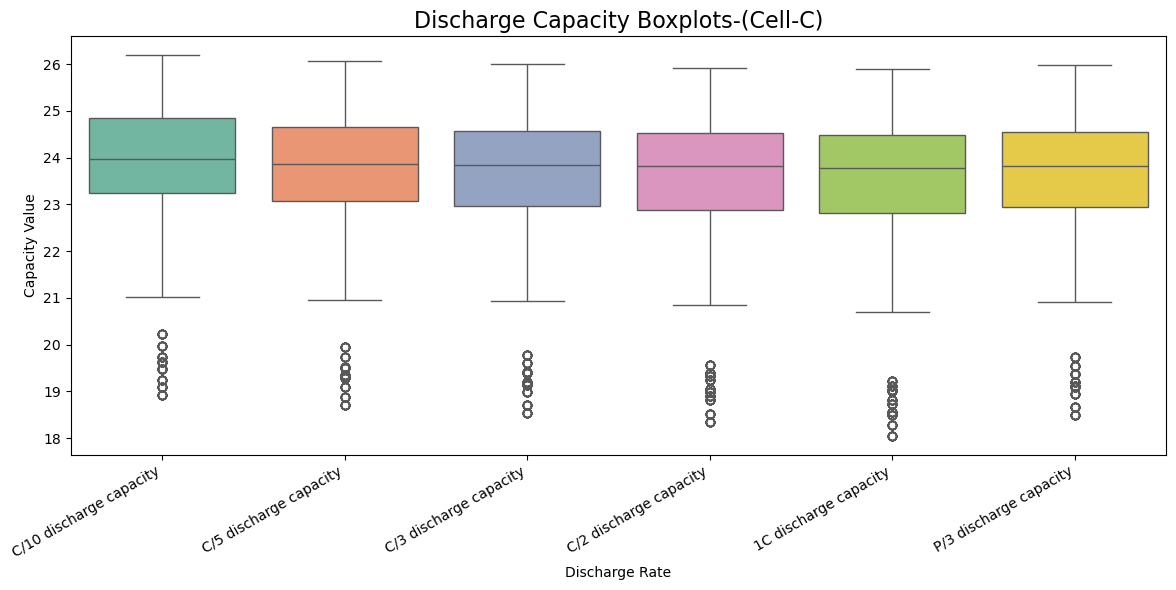

In [70]:
# Here, I wanted to compare the distribution of capacity across the different discharge rates.
# Boxplots shows the median, spread, and presence of outliers for each discharge condition.

target_vars = [
    'C/10 discharge capacity',
    'C/5 discharge capacity',
    'C/3 discharge capacity',
    'C/2 discharge capacity',
    '1C discharge capacity',
    'P/3 discharge capacity']
plt.figure(figsize=(12,6))

# boxplot
sns.boxplot(data=numeric_C[target_vars],palette='Set2')

plt.title("Discharge Capacity Boxplots-(Cell-C)", fontsize=16)
plt.xlabel("Discharge Rate")
plt.ylabel("Capacity Value")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The results show that the battery delivers more energy when discharged slowly and less energy when discharged quickly. At low discharge rates, the cell provides nearly its full capacity, but as the rate increases, the available capacity drops noticeably. This means that while the battery is well-suited for low-power applications that draw energy gradually, it will provide shorter runtimes in high-power applications that demand fast discharge.

#### Histograms  of discharge capacity at different rates (C/10 to P/3) for Cell‑C 

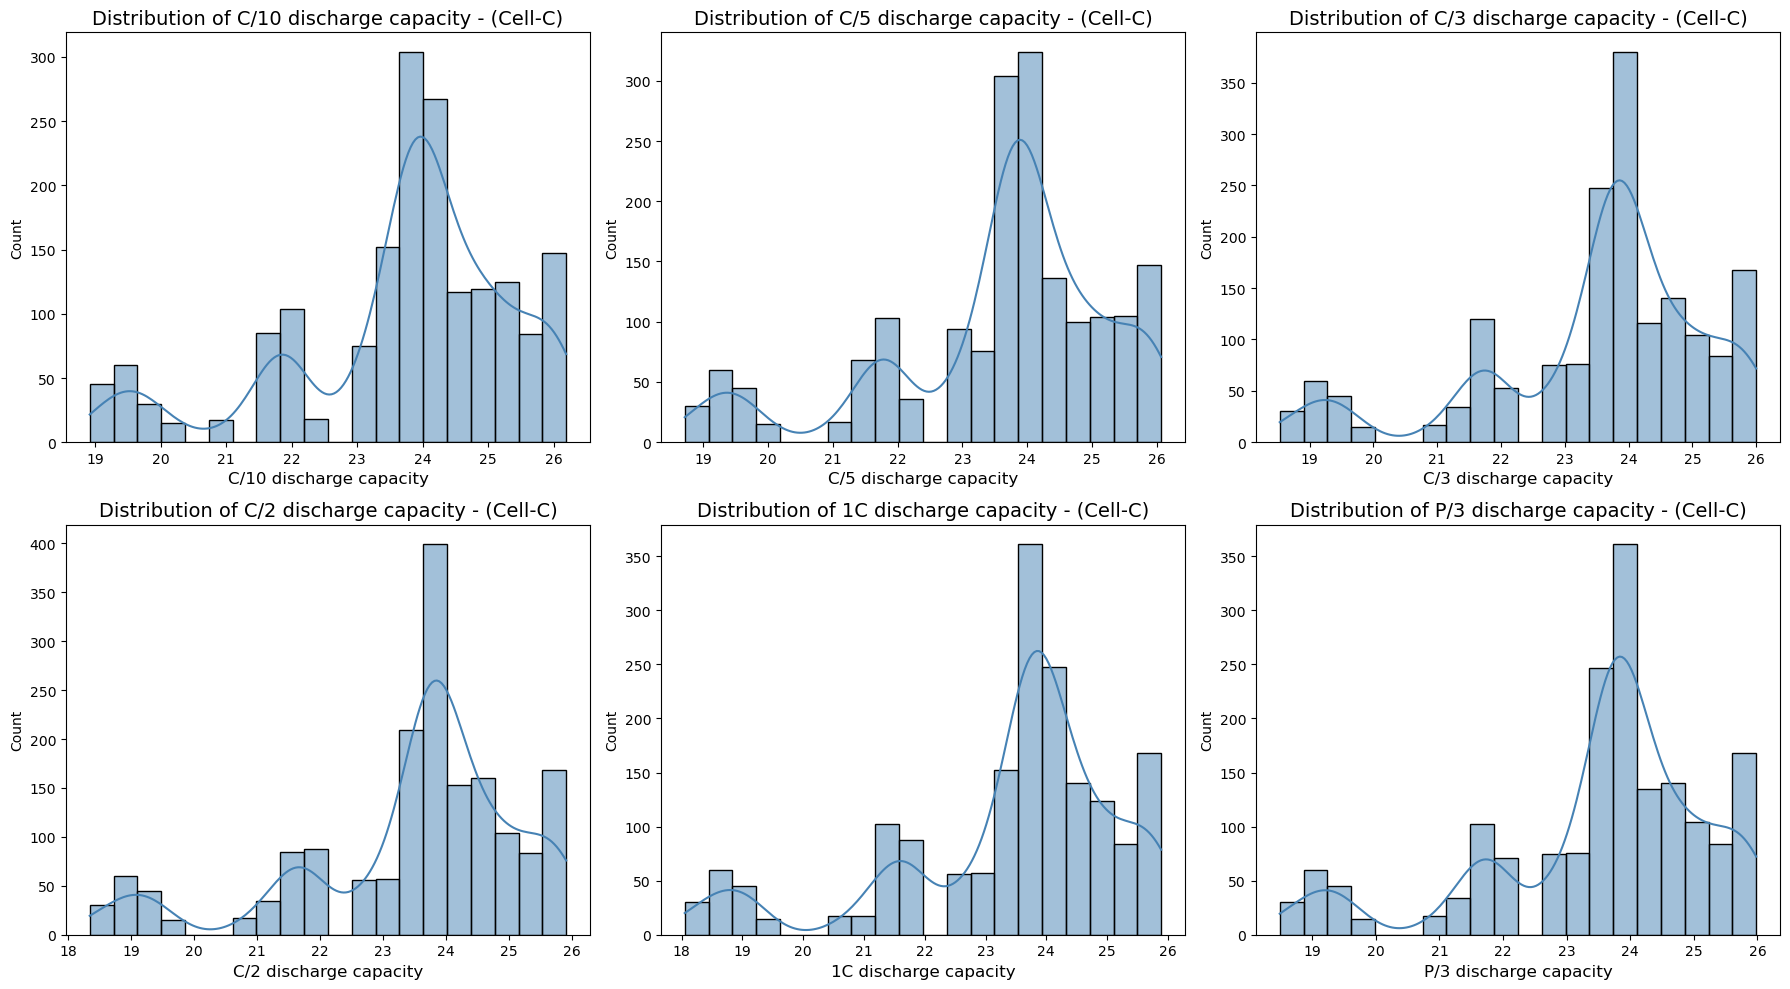

In [71]:
# In this step, I plotted histograms of the discharge capacity at different C-rates (C/10, C/5, C/3, C/2, 1C, and P/3) for Cell‑C. The goal was to 
# visualize the distribution of capacities at each discharge rate and show how frequently different capacity values occur. I also included kernel density 
# estimates (KDE)to show the overall shape and spread of the data.
    
# List of the target variables
target_vars = [
    'C/10 discharge capacity',
    'C/5 discharge capacity',
    'C/3 discharge capacity',
    'C/2 discharge capacity',
    '1C discharge capacity',
    'P/3 discharge capacity'
]

# Creating subplots: 2 rows × 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# histogram
for i, var in enumerate(target_vars):
    sns.histplot(data=numeric_C, x=var, bins=20, kde=True, color='steelblue', ax=axes[i])
    # Add "Cell -C" to the title
    axes[i].set_title(f'Distribution of {var} - (Cell-C)', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

The analysis shows that Cell‑C has higher discharge capacity at lower C‑rates (slow discharge) and lower capacity at higher C‑rates (fast discharge). At C/10, the cell provides nearly full capacity, while at 1C and above, the available capacity drops significantly. This shwo slower discharge allows more energy to be extracted, while faster discharge reduces usable capacity.

#### Boxplots summarizing the distribution of ambient temperature and state of charge (SOC) for Cell‑C

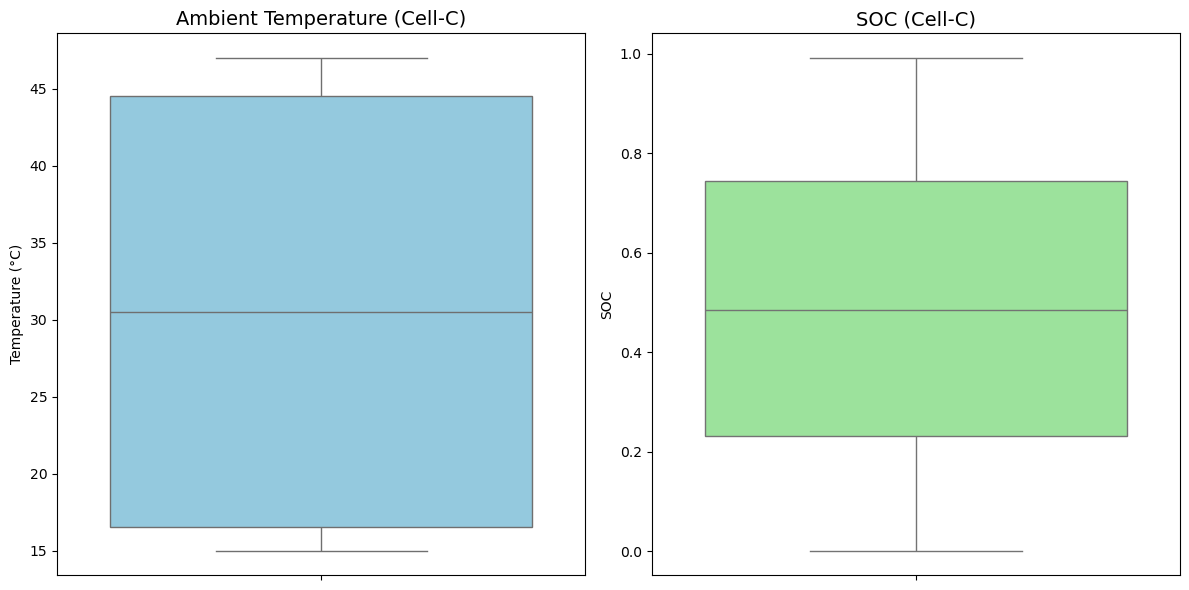

In [72]:
# In this step, I created side‑by‑side boxplots to show the distribution of ambient temperature and state of charge (SOC) for Cell‑C. These plots 
#summarize the spread, median, and any outliers in each variable, making it easy to compare their variability and typical ranges.
    
# Creating side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot for temperature_ambient
sns.boxplot(y=numeric_C['temperature_ambient'], color='skyblue', ax=axes[0])
axes[0].set_title("Ambient Temperature (Cell-C)", fontsize=14)
axes[0].set_ylabel("Temperature (°C)")

# Boxplot for soc
sns.boxplot(y=numeric_C['soc'], color='lightgreen', ax=axes[1])
axes[1].set_title("SOC (Cell-C)", fontsize=14)
axes[1].set_ylabel("SOC")

plt.tight_layout()
plt.show()

The ambient temperature for Cell‑C ranges from about 15 °C to 47 °C, with a median around 31 °C. The interquartile range, middle 50% of values fall between roughly 22 °C and 38 °C. Seems like that the cell was tested under a moderate to warm environment, with some measurements at both cooler (15 °C) and hotter extremes (47 °C).
The SOC values for Cell‑C ranges from 0 to 1, with a median around 0.5. The interquartile range, middle 50% of values fall between 0.3 and 0.7 and shows that most of the SOC values falls around mid‑range levels. I think SOC at 0  indicate fully discharged states and SOC at 1 indicates fully charged states. From, the SOC distribution seems like cell C was tested under a different range of charging conditions not just at one fixed level.

#### Boxplots comparing ambient temperature and SOC for Cell‑C under discharge and charge conditions

C:\Users\uhabiba\AppData\Local\Temp\1\ipykernel_24124\2256139660.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=numeric_C,x='direction_num',y='temperature_ambient',ax=axes[0],palette="Set2")
C:\Users\uhabiba\AppData\Local\Temp\1\ipykernel_24124\2256139660.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Discharge (0)", "Charge (1)"])
C:\Users\uhabiba\AppData\Local\Temp\1\ipykernel_24124\2256139660.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=numeric_C,x='direction_num',y='soc',ax=axes[1],palette="Set2")
C:\Users\uhabiba\AppData\Local\Temp\1\ipykernel_2412

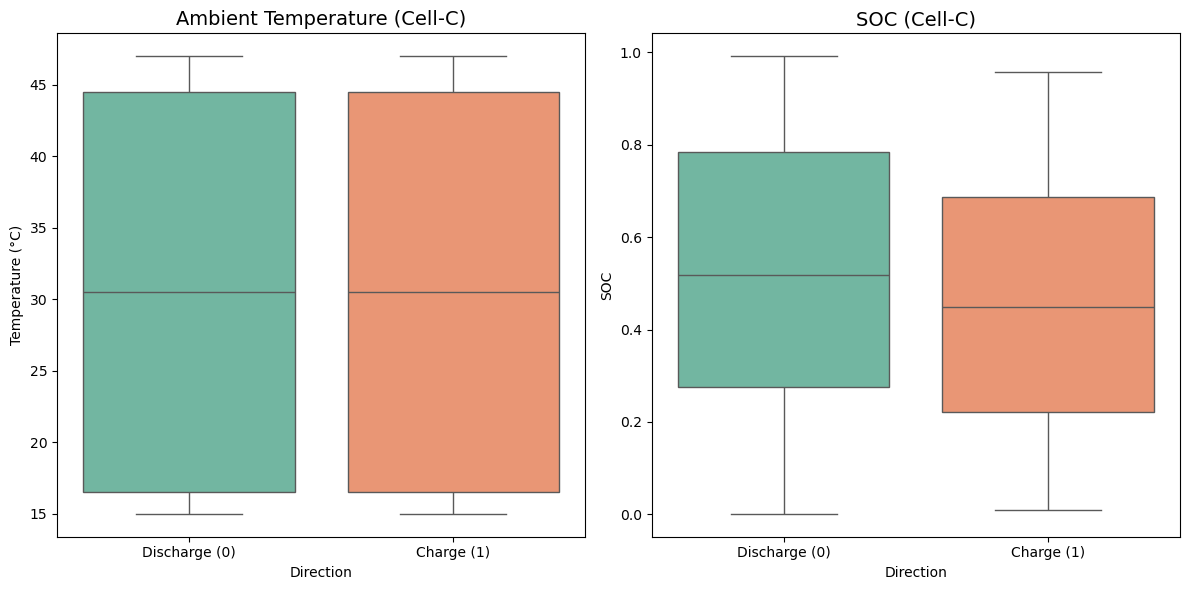

In [73]:
# Here, I wanted to see if there are any differences in the distributions of the ambient temperature and SOC depending on whether the cell is
# charging or discharging.

# Creating side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot for temperature_ambient
sns.boxplot(data=numeric_C,x='direction_num',y='temperature_ambient',ax=axes[0],palette="Set2")
axes[0].set_title("Ambient Temperature (Cell-C)", fontsize=14)
axes[0].set_xlabel("Direction")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_xticklabels(["Discharge (0)", "Charge (1)"]) 

# Boxplot for soc
sns.boxplot(data=numeric_C,x='direction_num',y='soc',ax=axes[1],palette="Set2")
axes[1].set_title("SOC (Cell-C)", fontsize=14)
axes[1].set_xlabel("Direction")
axes[1].set_ylabel("SOC")
axes[1].set_xticklabels(["Discharge (0)", "Charge (1)"]) 

plt.tight_layout()
plt.show()

For the Ambient Temperature (Cell‑C) graph, the temperature ranges are broadly similar for both discharge and charge, falls between 15 °C to 47 °C, with a median around 31 °C. This shows that the cell was tested under comparable environmental conditions in both directions.

For the SOC (Cell‑C)gaph, the SOC distribution differs between discharge and charge. During discharge, the SOC values are generally higher, median closer to mid‑range, while during charge, the SOC values are lower on average. I think this is expected behavior, the SOC decreases as the cell discharges and SOC increases during charging cycles.

#### Histograms of ambient temperature and SOC values for Cell‑C

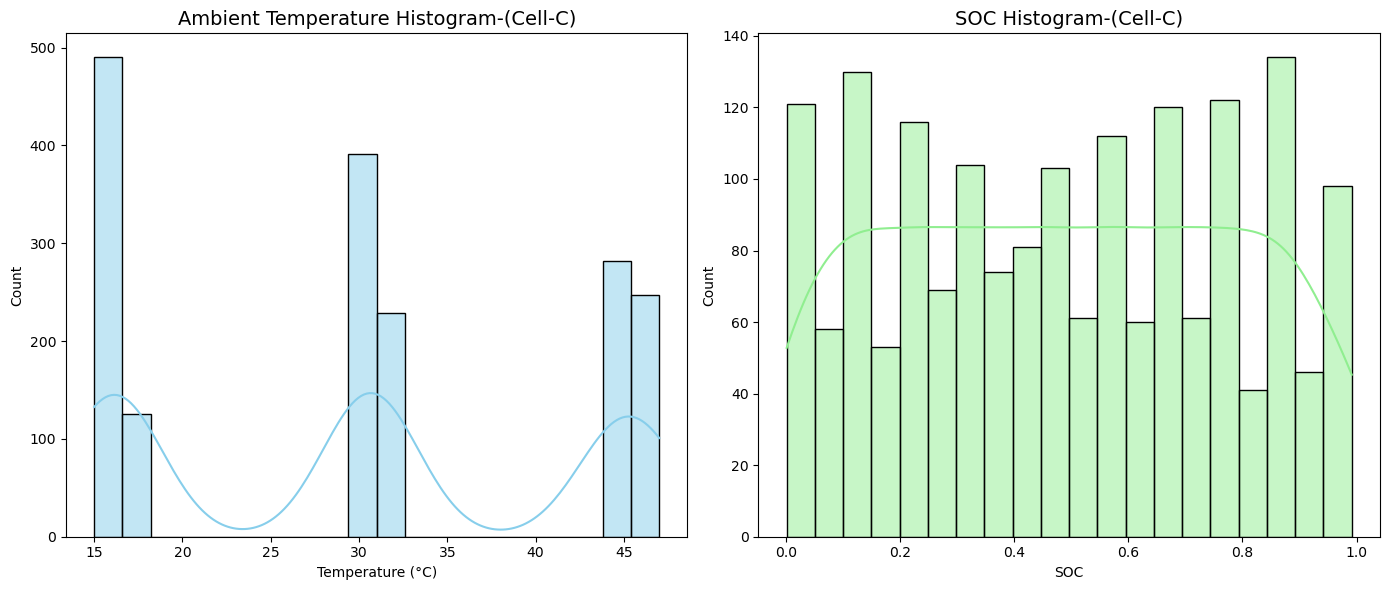

In [74]:
# In this step, I plotted side‑by‑side histograms for Cell‑C, one showing the distribution of ambient temperature values and the other showing the 
# distribution of state of charge (SOC) values.The goal was to see how frequently different values occur and whether the data is concentrated in certain
# ranges or spread out. I also included kernel density estimates (KDE)to show the overall shape and and the distribution of the data. 

# Creating side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Histogram for temperature_ambient
sns.histplot(data=numeric_C, x='temperature_ambient', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("Ambient Temperature Histogram-(Cell-C)", fontsize=14)
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Count")

# Histogram for soc
sns.histplot(data=numeric_C,x='soc',bins=20,kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title("SOC Histogram-(Cell-C)", fontsize=14)
axes[1].set_xlabel("SOC")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

For the Ambient Temperature Histogram-(Cell-C) graph,the temperature values falls between 15 °C to 47 °C, with most measurements clustering around the mid‑20s to low‑30s °C. The distribution suggests that the cell was typically tested under moderate to warm conditions, with fewer instances at the cooler and hotter extremes.

For the SOC Histogram-(Cell-C) graph, the SOC values span the full range from 0, fully discharge to 1, fully charged, but the distribution is concentrated around the middle range (0.3–0.7). This indicates that the cell was most often observed in partially charged states, while fully charged or fully discharged states were less frequent.

#### Scatter plot of ambient temperature versus SOC for Cell‑C

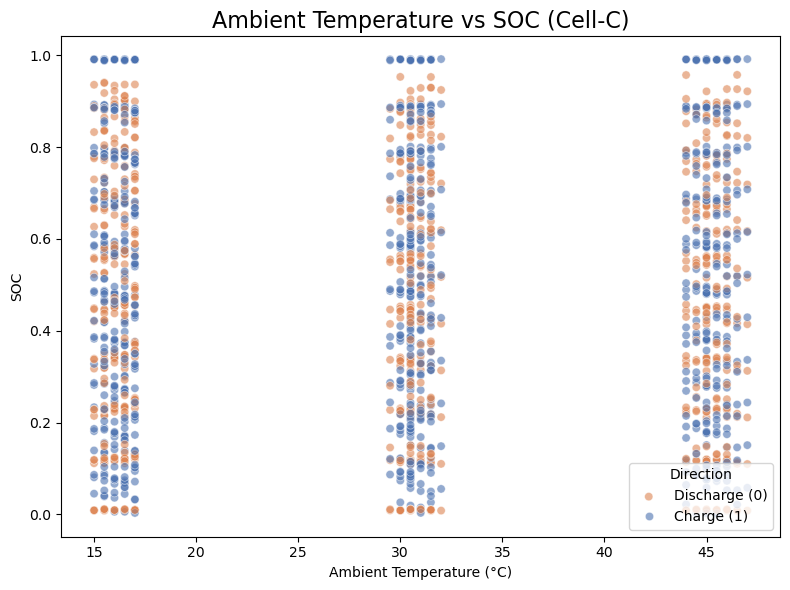

In [75]:
# Here I wanted to see the relationship between ambient temperature and SOC, and to compare how this relationship differs during charging vs discharging
plt.figure(figsize=(8,6))
sns.scatterplot(data=new_data_C, x='temperature_ambient', y='soc', hue='direction_num',palette={0: '#4C72B0', 1: '#DD8452'},alpha=0.6)

plt.title("Ambient Temperature vs SOC (Cell-C)", fontsize=16)
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("SOC")
plt.legend(title="Direction", labels=["Discharge (0)", "Charge (1)"])
plt.tight_layout()
plt.show()

#### Scatter plots with regression lines showing the relationship between SOC and discharge capacity at different C‑rates for Cell‑C

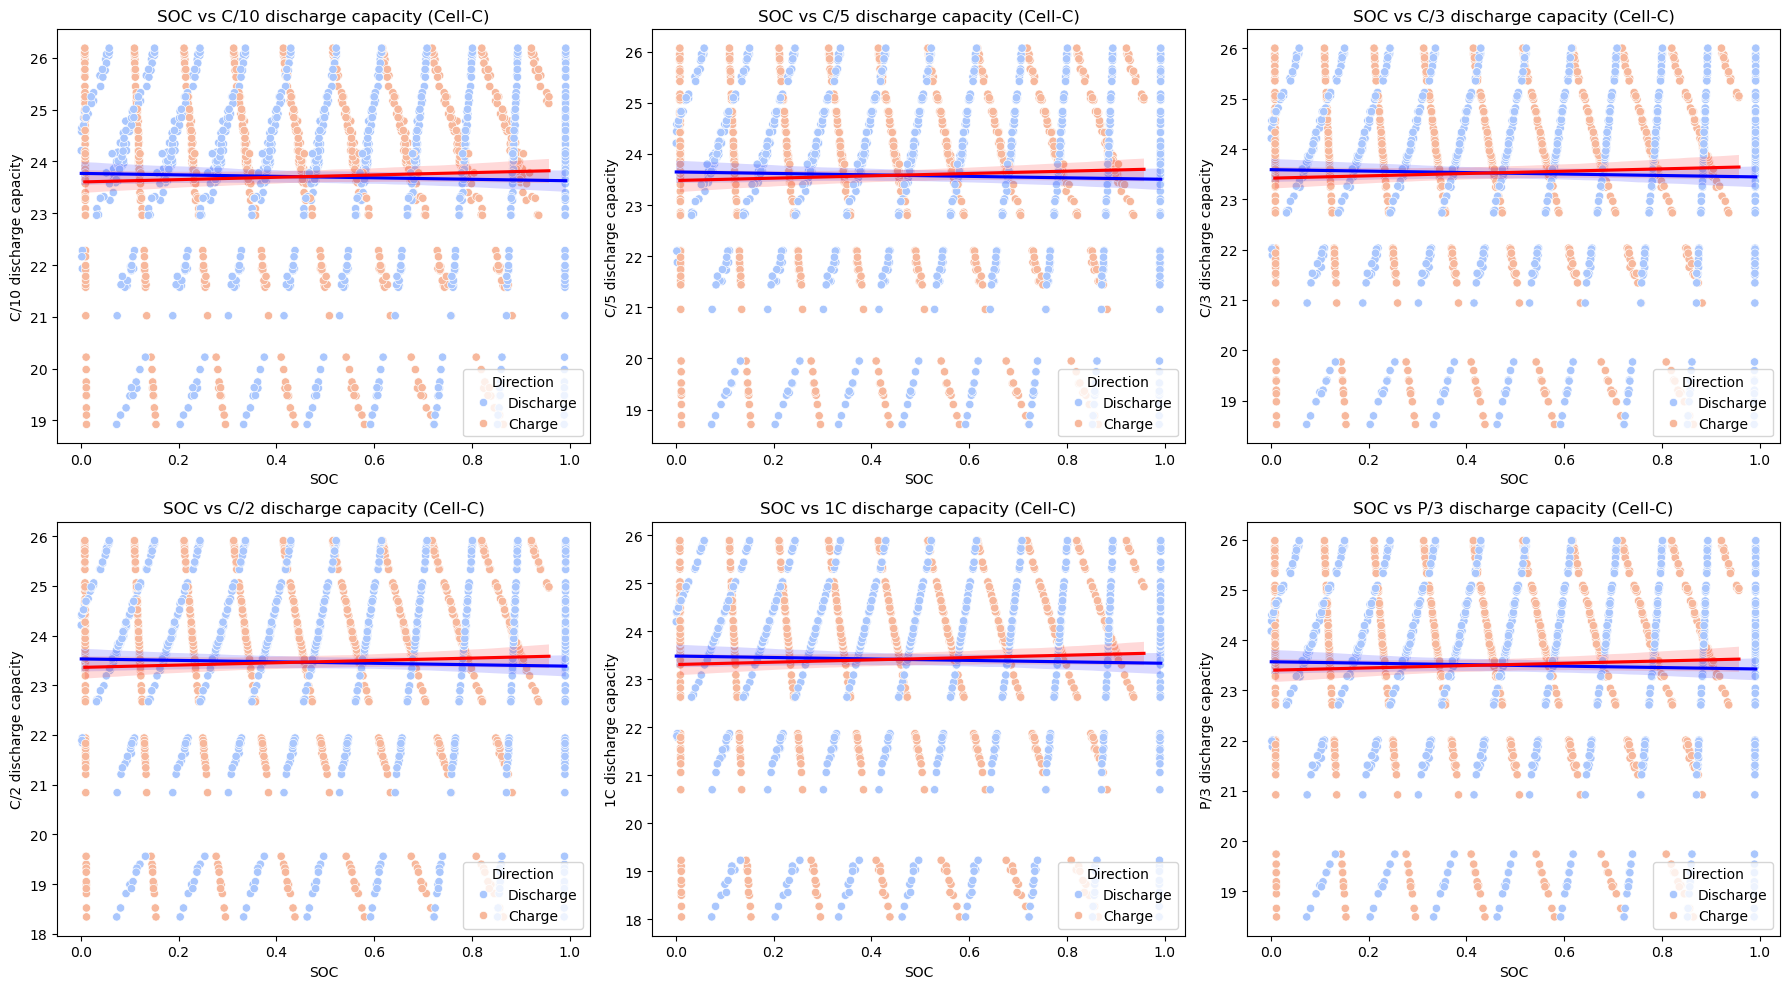

In [76]:
# Here, I wanted to compare how capacity changes with SOC under both charging and discharging conditions, and to visualize the overall trends for
# each rate.
# List of target variables
target_vars = [
    'C/10 discharge capacity',
    'C/5 discharge capacity',
    'C/3 discharge capacity',
    'C/2 discharge capacity',
    '1C discharge capacity',
    'P/3 discharge capacity']

# Creating 3x2 subplot 
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)
axes = axes.flatten()

# Creating loop through each target variable
for i, target in enumerate(target_vars):
    ax = axes[i]
    
    # Scatter plot colored by direction_num (when discharge =0, charge =1)
    sns.scatterplot(data=new_data_C, x='soc', y=target, hue='direction_num',palette='coolwarm',ax=ax)
    
    # Adding regression lines for each category
    sns.regplot(data=new_data_C[new_data_C['direction_num'] == 0], x='soc', y=target, scatter=False, ax=ax, color='blue',
                line_kws={'label': 'Discharge Trend'})
    sns.regplot(data=new_data_C[new_data_C['direction_num'] == 1], x='soc', y=target, scatter=False, ax=ax, color='red',
                line_kws={'label': 'Charge Trend'})
    
    # Titles and labels
    ax.set_title(f'SOC vs {target} (Cell-C)')
    ax.set_xlabel('SOC')
    ax.set_ylabel(target)
    
    # Legend 
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], ['Discharge', 'Charge', 'Trend Lines'], title='Direction')

# Adjusting layout
plt.tight_layout()
plt.show()


#### Scatter plots with regression lines showing the relationship between ambient temperature and discharge capacity at different C‑rates for Cell‑C

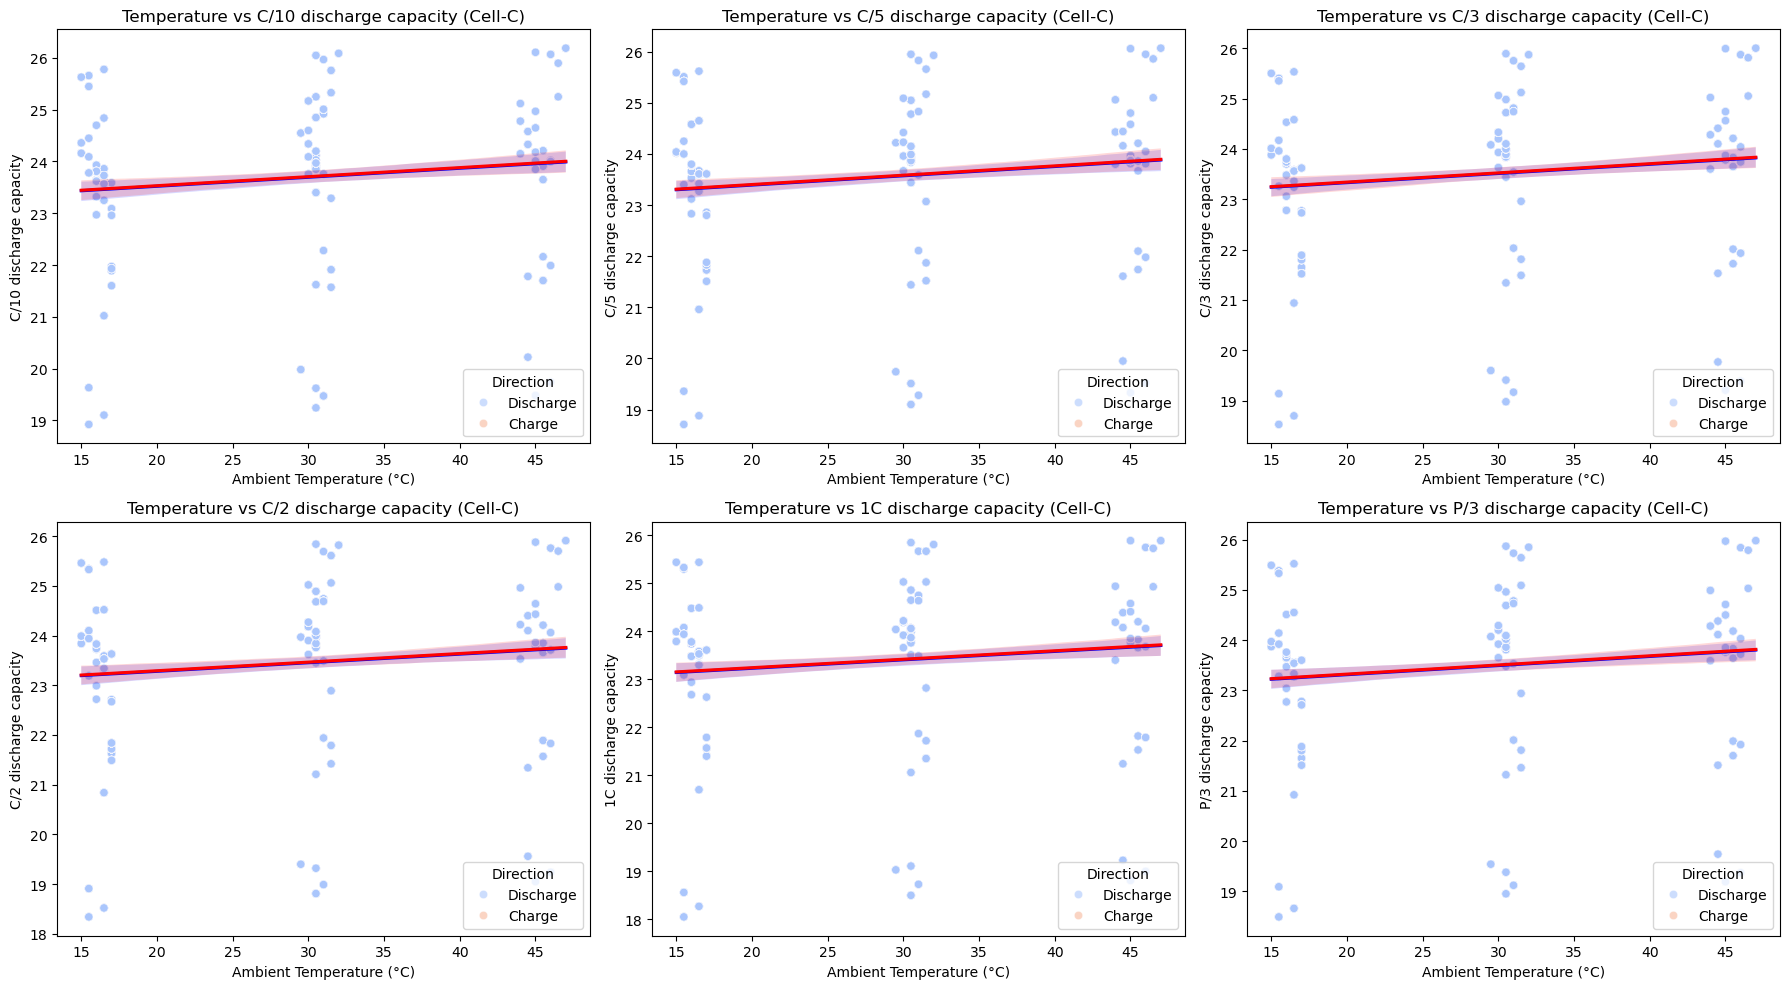

In [77]:
# Here, I wanted to compare how temperature effects capacity under charging and discharging conditions at different C‑rates.
# List of target variables
target_vars = [
    'C/10 discharge capacity',
    'C/5 discharge capacity',
    'C/3 discharge capacity',
    'C/2 discharge capacity',
    '1C discharge capacity',
    'P/3 discharge capacity']

# Creating 3x2 subplot 
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)
axes = axes.flatten()

# Creating loop through each target variable
for i, target in enumerate(target_vars):
    ax = axes[i]
    
    # Scatter plot colored by direction_num
    sns.scatterplot(data=new_data_C,x='temperature_ambient', y=target, hue='direction_num', palette='coolwarm', alpha=0.6, ax=ax)
    
    # Adding regression lines for each category
    sns.regplot(
        data=new_data_C[new_data_C['direction_num'] == 0], x='temperature_ambient', y=target, scatter=False, ax=ax, color='blue',
        line_kws={'label': 'Discharge Trend'})
    sns.regplot(
        data=new_data_C[new_data_C['direction_num'] == 1], x='temperature_ambient', y=target, scatter=False, ax=ax, color='red',
        line_kws={'label': 'Charge Trend'})
    
    # Titles and labels
    ax.set_title(f'Temperature vs {target} (Cell-C)')
    ax.set_xlabel('Ambient Temperature (°C)')
    ax.set_ylabel(target)
    
    # Legend 
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], ['Discharge', 'Charge', 'Trend Lines'], title='Direction')

# Adjusting layout
plt.tight_layout()
plt.show()

#### Voltage traces over time for Cell‑C 

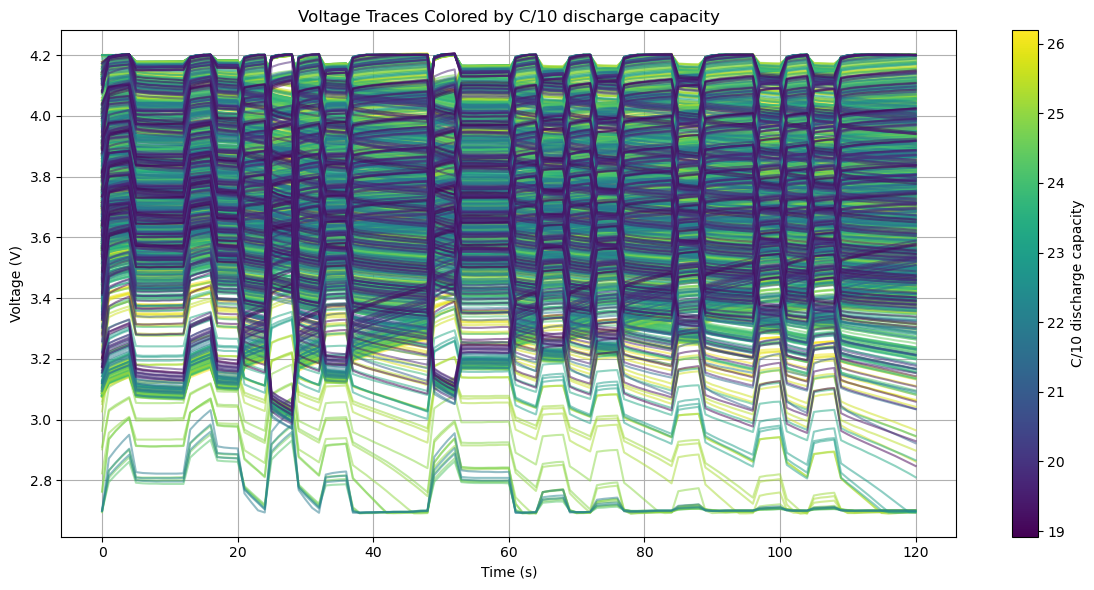

In [78]:
# Here, I wanted to visualize how the pulse data, (for this section I choose voltage over time) evolves, and how that evolution
# differs depending on the discharge capacity.

import matplotlib.cm as cm

# Choosing voltage columns and time
voltage_columns = [col for col in numeric_C.columns if col.startswith('voltage_')]
voltage_times = [float(col.split('_')[1].replace('s', '')) for col in voltage_columns]
sorted_indices = np.argsort(voltage_times)
sorted_voltage_columns = [voltage_columns[i] for i in sorted_indices]
sorted_voltage_times = [voltage_times[i] for i in sorted_indices]

# Choosing a target variable 
target_variable = 'C/10 discharge capacity'
target_values = new_data_C[target_variable]

# Normalizing target values for color mapping
norm = plt.Normalize(target_values.min(), target_values.max())
cmap = cm.viridis  

# Creating figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each voltage trace
for i in range(len(numeric_C)):
    voltage_trace = numeric_C.iloc[i][sorted_voltage_columns].values
    color = cmap(norm(target_values.iloc[i]))
    ax.plot(sorted_voltage_times, voltage_trace, color=color, alpha=0.5)

# Adding colorbar linked to the same axis
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(target_variable)

# Labels and title
ax.set_title(f'Voltage Traces Colored by {target_variable}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.grid(True)
plt.tight_layout()
plt.show()


#### Voltage traces over time for Cell‑C at different discharge rates (target variables)

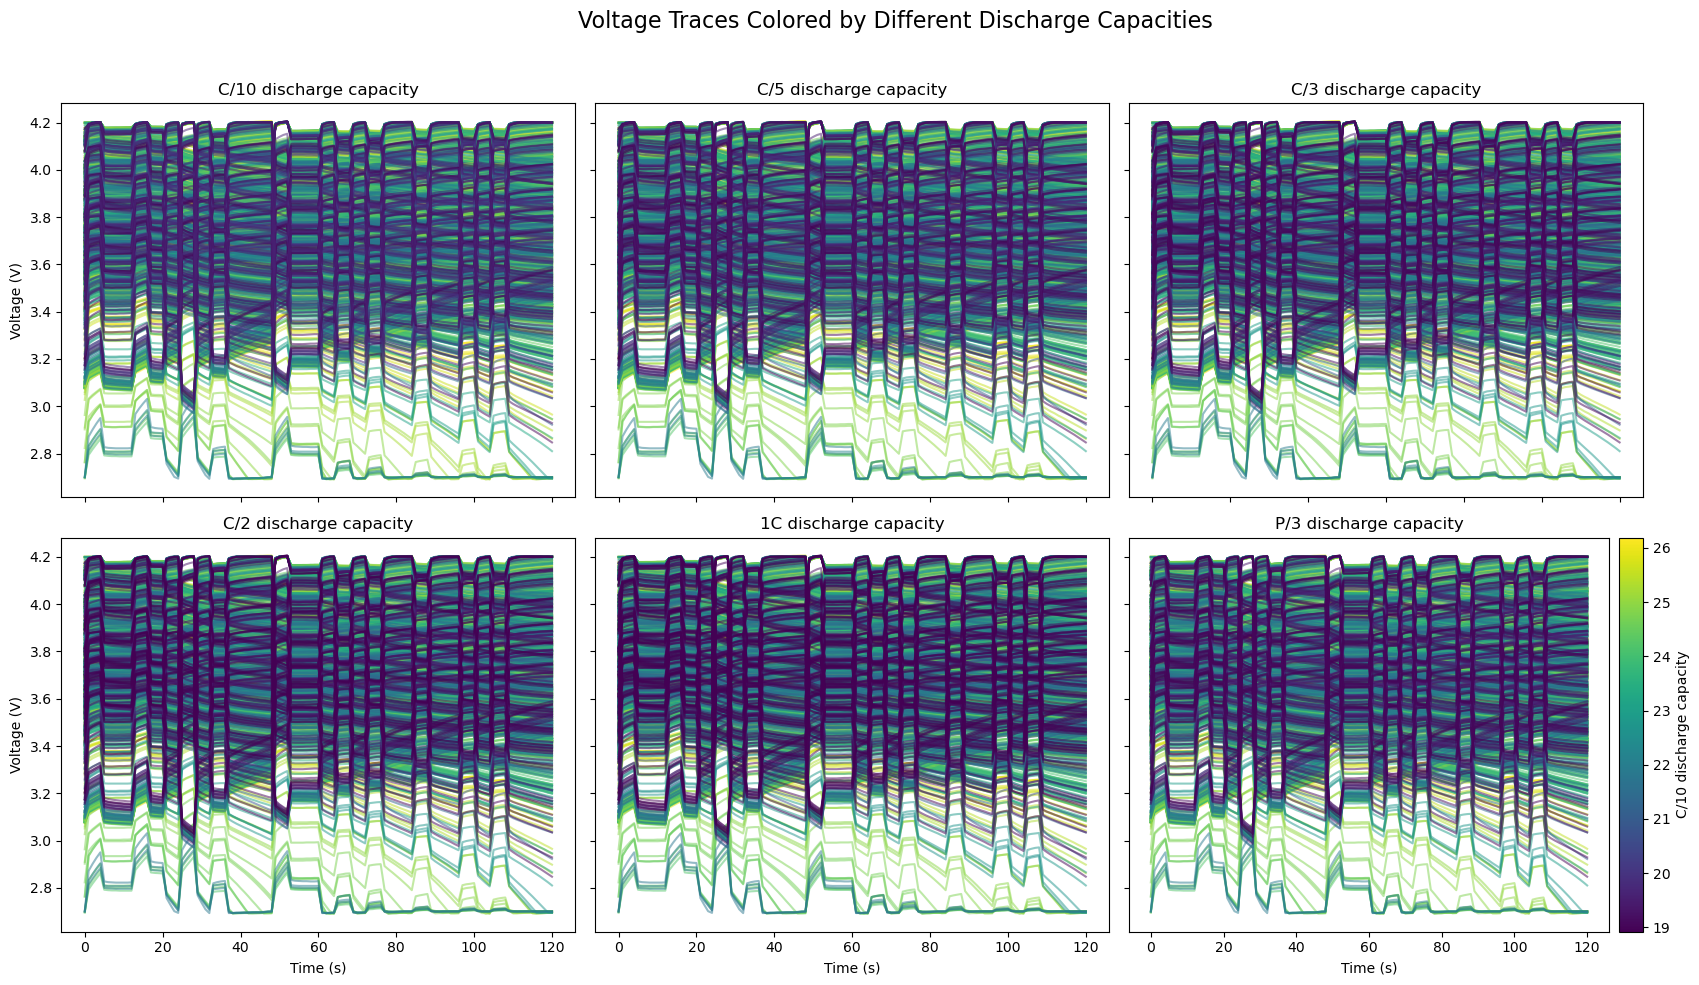

In [79]:
# Here I wanted to visualize how voltage behavior during pulse tests changes across different discharge rates and to compare patterns between them.
target_variables = [
    'C/10 discharge capacity',
    'C/5 discharge capacity',
    'C/3 discharge capacity',
    'C/2 discharge capacity',
    '1C discharge capacity',
    'P/3 discharge capacity']

# Setting up subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Choosing voltage columns and time
voltage_columns = [col for col in numeric_C.columns if col.startswith('voltage_')]
voltage_times = [float(col.split('_')[1].replace('s', '')) for col in voltage_columns]
sorted_indices = np.argsort(voltage_times)
sorted_voltage_columns = [voltage_columns[i] for i in sorted_indices]
sorted_voltage_times = [voltage_times[i] for i in sorted_indices]

# Using the first target variable to define color scale, shared across all subplots
reference_target = new_data_C[target_variables[0]]
norm = plt.Normalize(reference_target.min(), reference_target.max())
cmap = cm.viridis

# Plotting each subplot
for i, target_variable in enumerate(target_variables):
    ax = axes[i]
    target_values = new_data_C[target_variable]

    for j in range(len(numeric_C)):
        voltage_trace = numeric_C.iloc[j][sorted_voltage_columns].values
        color = cmap(norm(target_values.iloc[j]))  # Use shared norm for consistent color scale
        ax.plot(sorted_voltage_times, voltage_trace, color=color, alpha=0.5)

    ax.set_title(target_variable)
    if i % 3 == 0:
        ax.set_ylabel('Voltage (V)')
    if i >= 3:
        ax.set_xlabel('Time (s)')

# Adding a colorbar on the right side of the figure
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Adding axis 
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.1)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label=target_variables[0])  # Labelling with the first target variable

plt.suptitle('Voltage Traces Colored by Different Discharge Capacities', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.96]) 
plt.show()


# PCA for Cell type C

Number of components chosen: 4
Explained variance ratio: [0.47753568 0.28988615 0.16981939 0.02489446]


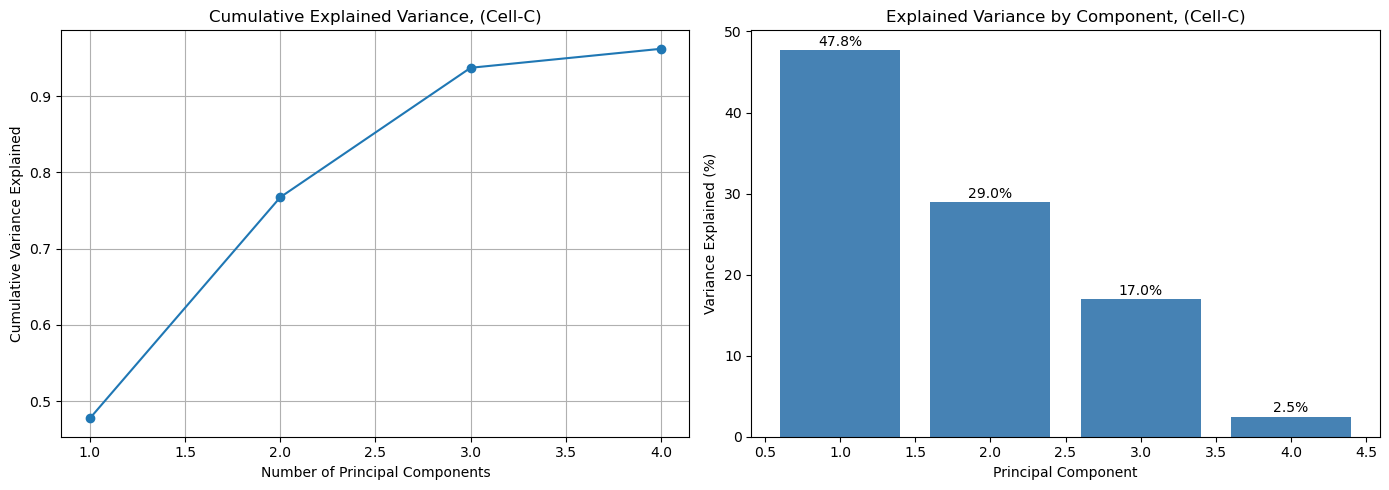

In [80]:
# Standardizing or scalling the data (important for PCA)
scaler = StandardScaler()
numeric_C_scaled = scaler.fit_transform(numeric_C)

# Fitting PCA to retain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(numeric_C_scaled )

print("Number of components chosen:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Explained variance ratios
explained_var = pca.explained_variance_ratio_

# Creating subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative explained variance (line plot)
axes[0].plot(range(1, len(explained_var)+1), np.cumsum(explained_var), marker='o', linestyle='-')
axes[0].set_title('Cumulative Explained Variance, (Cell-C)')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].grid(True)

#Plot 2: Individual explained variance (bar plot) 
axes[1].bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue')
axes[1].set_title('Explained Variance by Component, (Cell-C)')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')

# Adding percentage labels on top of bars
for i, v in enumerate(explained_var * 100, start=1):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

#### Top 10 features contributing to the PC1 -PC4

In [81]:
## Trying to see which features drive each PC:

# Use the original column names from numeric_C
loadings = pd.DataFrame(pca.components_.T, index=numeric_C.columns,columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# Show top 10 features contributing most to PC1, PC2, PC3, and PC4
top_loadings = (loadings[['PC1', 'PC2', 'PC3', 'PC4']].abs(). sort_values(by='PC1', ascending=False).head(10))

print(top_loadings)


                    PC1       PC2       PC3       PC4
voltage_47.0s  0.091244  0.000525  0.000108  0.006983
voltage_48.0s  0.091243  0.000191  0.000124  0.006689
voltage_46.0s  0.091239  0.001277  0.000081  0.007287
voltage_45.0s  0.091228  0.002052  0.000041  0.007594
voltage_72.0s  0.091224  0.000884  0.000186  0.006597
voltage_71.0s  0.091224  0.001919  0.000160  0.006933
voltage_70.0s  0.091211  0.003125  0.000128  0.007345
voltage_44.0s  0.091211  0.002847  0.000009  0.007921
voltage_78.0s  0.091210  0.000746  0.000224  0.006361
voltage_77.0s  0.091208  0.002246  0.000200  0.006777


Here, we can see that the top 10 features contributing to first principal component, PC1 is almost entirely driven by voltage measurements between 44–48 seconds, 70–72 seconds, and 77–78 seconds. Their loadings are very similar (around 0.091) which means PC1 is dominated by voltage behavior across these time intervals.

But, these features contribute very little to PC2, PC3, and PC4 (almost close to zero), this indicates that these voltage features are not strongly influencing the PC2, PC3, and PC4, which are likely shaped by other variables (may be SOC, temperature, or later voltage points not shown in this top 10 list).

### Bar chart of the top 10 voltage features contributing to PC1–PC4

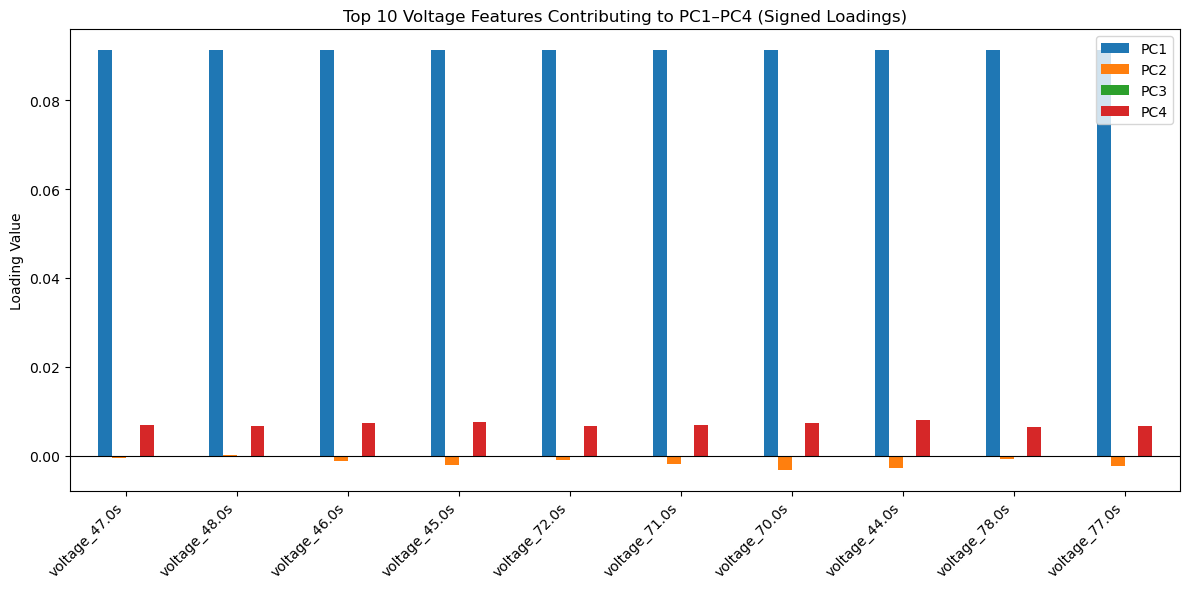

In [82]:
# Here, I wanted to see how the top 10 voltage features that contribute to PC1, PC2, PC3, and PC4 and in what direction (positive or negative).

# Filtering voltage columns 
voltage_columns = [col for col in numeric_C.columns if col.startswith('voltage_')]

# Subseting the loadings - Keeping only the loadings for voltage columns
voltage_loadings = loadings.loc[voltage_columns, ['PC1','PC2','PC3','PC4']]

# Getting the top 10 voltages 
top_voltage_features = (voltage_loadings.abs().max(axis=1).sort_values(ascending=False).head(10).index)
top_voltage_loadings_signed = voltage_loadings.loc[top_voltage_features]

# Bar plot
top_voltage_loadings_signed.plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Voltage Features Contributing to PC1–PC4 (Signed Loadings)")
plt.ylabel("Loading Value")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

#### Bar chart of PCA loadings for PC1–PC4 at 10‑second intervals 

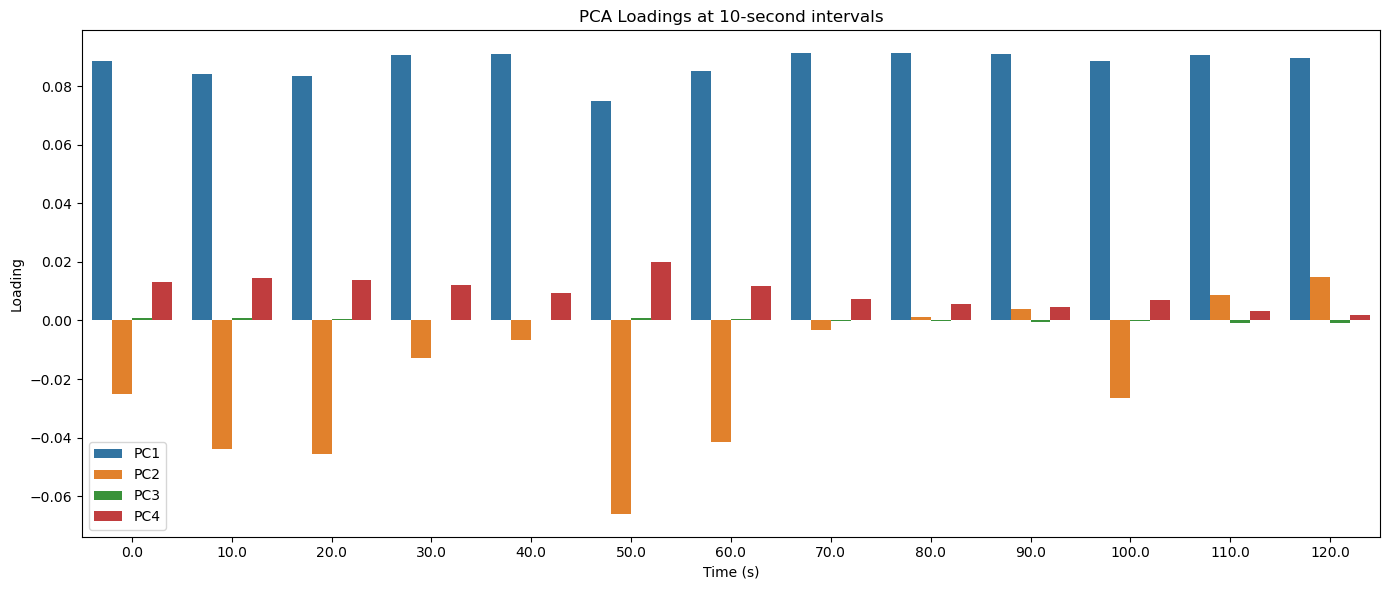

In [83]:
# Here, I wanted to see how the PC1, PC2, PC3, and PC4 varies at specific time intervals, so it will be easier to see which PCs dominate at
# different stages of the voltage trace.
# For this step, I downsamples the PCA loadings to every 10 seconds instead of plotting every single one

# Extracting loadings for PC1–PC4 for voltage features

pc_voltage_loadings = loadings.loc[voltage_columns, ['PC1', 'PC2', 'PC3', 'PC4']]

# Sortting by time 

pc_voltage_loadings['time'] = voltage_times 
pc_voltage_loadings = pc_voltage_loadings.sort_values(by='time')

# Downsample to every 10 seconds
mask = pc_voltage_loadings['time'] % 10 == 0
subset = pc_voltage_loadings[mask]

subset_melted = subset.melt(id_vars='time', var_name='PC', value_name='Loading')

plt.figure(figsize=(14, 6))
sns.barplot(data=subset_melted, x='time', y='Loading', hue='PC')
plt.title('PCA Loadings at 10‑second intervals')
plt.xlabel('Time (s)')
plt.ylabel('Loading')
plt.legend()
plt.tight_layout()
plt.show()

Here, I am not sure, why it showing PC3 contributing less than PC4. May be beacause how I downsampled for for 10 seconds and it may have hidden the strongest features for PC3.

#### Heatmap of the top 10 voltage features to show their contributions to PC1–PC4

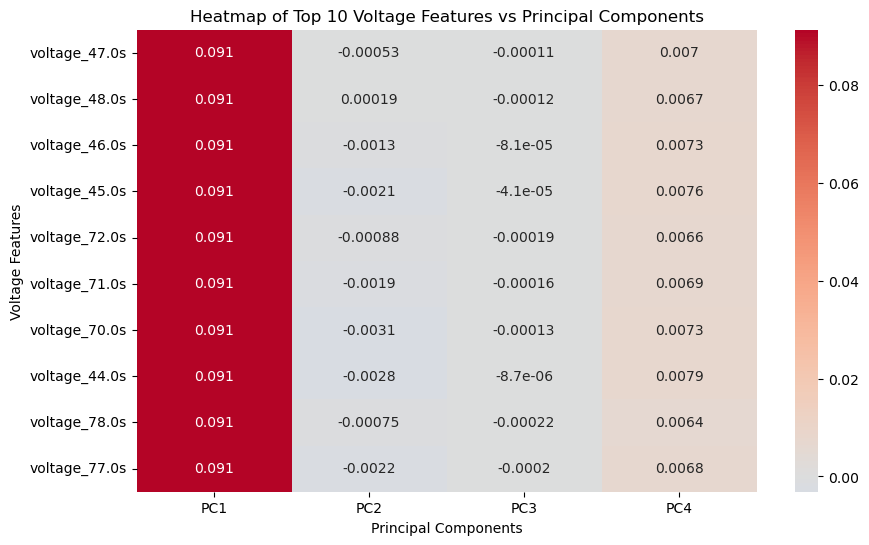

In [84]:
# Here, I wanted to visually compare how each top voltage feature contributes across multiple PCs at once, making it easy to see patterns of influence
#Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(top_voltage_loadings_signed, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap of Top 10 Voltage Features vs Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Voltage Features")
plt.show()

#### Line plot-PC1 loadings of voltage features plotted over time

C:\Users\uhabiba\AppData\Local\Temp\1\ipykernel_24124\4223598718.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_loadings = [pc1_voltage_loadings[i] for i in sorted_indices]


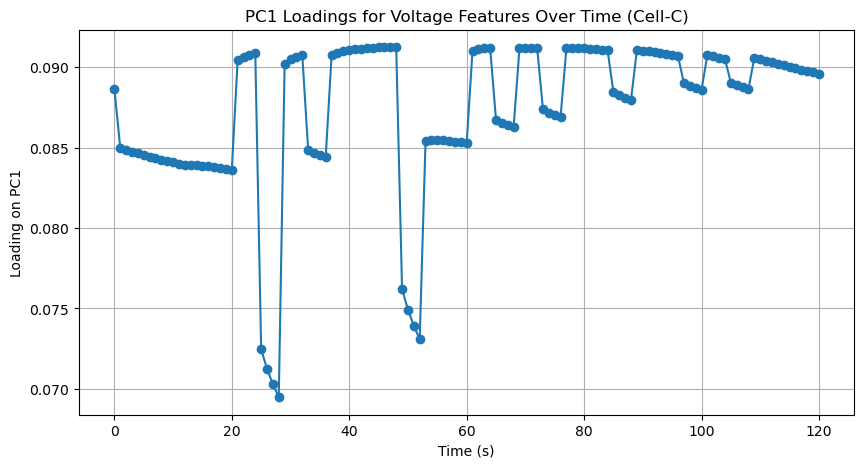

In [85]:
# Here, I wanted to visualize which time points in the voltage trace has most effect in shaping PC1
# It will show how strongly each voltage measurement contributes to PC1 across the pulse test

# Filtering voltage columns 
voltage_columns = [col for col in numeric_C.columns if col.startswith('voltage_')]

# Extracting PC1 loadings for voltage features
pc1_voltage_loadings = loadings.loc[voltage_columns, 'PC1']

# Extracting time from column names (like-'voltage_0.0s' → 0.0)
voltage_times = [float(col.split('_')[1].replace('s', '')) for col in voltage_columns]

# Sortting by time
sorted_indices = sorted(range(len(voltage_times)), key=lambda i: voltage_times[i])
sorted_times = [voltage_times[i] for i in sorted_indices]
sorted_loadings = [pc1_voltage_loadings[i] for i in sorted_indices]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(sorted_times, sorted_loadings, marker='o')
plt.title('PC1 Loadings for Voltage Features Over Time (Cell-C)')
plt.xlabel('Time (s)')
plt.ylabel('Loading on PC1')
plt.grid(True)
plt.show()


#### Line plot-PCA loadings of voltage features over time for PC1–PC4

C:\Users\uhabiba\AppData\Local\Temp\1\ipykernel_24124\2359177209.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(voltage_times, example_voltage_trace.values, 'k--', color='black')


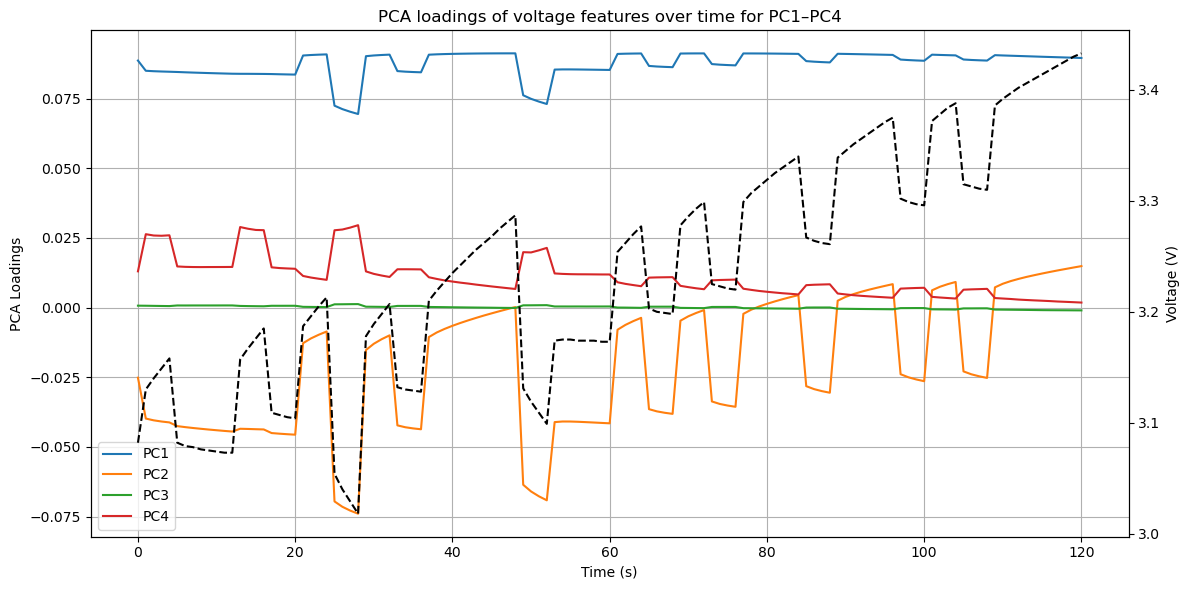

In [86]:
# Here, I wanted to visualize how different principal components are influenced by voltage features at specific times, and to compare this against 
# the actual voltage profile.

# Extracting and sortting voltage features and times
voltage_columns = sorted([c for c in numeric_C.columns if c.startswith('voltage_')], key=lambda x: float(x.split('_')[1].replace('s', '')))
voltage_times = [float(c.split('_')[1].replace('s', '')) for c in voltage_columns]

# PCA loadings for voltage features 
pc_voltage_loadings = (loadings.loc[voltage_columns, ['PC1', 'PC2', 'PC3', 'PC4']].assign(time=voltage_times))
example_voltage_trace = numeric_C.loc[numeric_C.index[0], voltage_columns] 

# Plot 
fig, ax1 = plt.subplots(figsize=(12, 6))

# PCA loadings
pc_voltage_loadings.plot(x='time', ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('PCA Loadings')
ax1.grid(True)

# Voltage trace on secondary axis
ax2 = ax1.twinx()
ax2.plot(voltage_times, example_voltage_trace.values, 'k--', color='black')
ax2.set_ylabel('Voltage (V)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('PCA loadings of voltage features over time for PC1–PC4')
plt.tight_layout()
plt.show()


#### Line plot - Absolute PCA loadings of voltage features over time

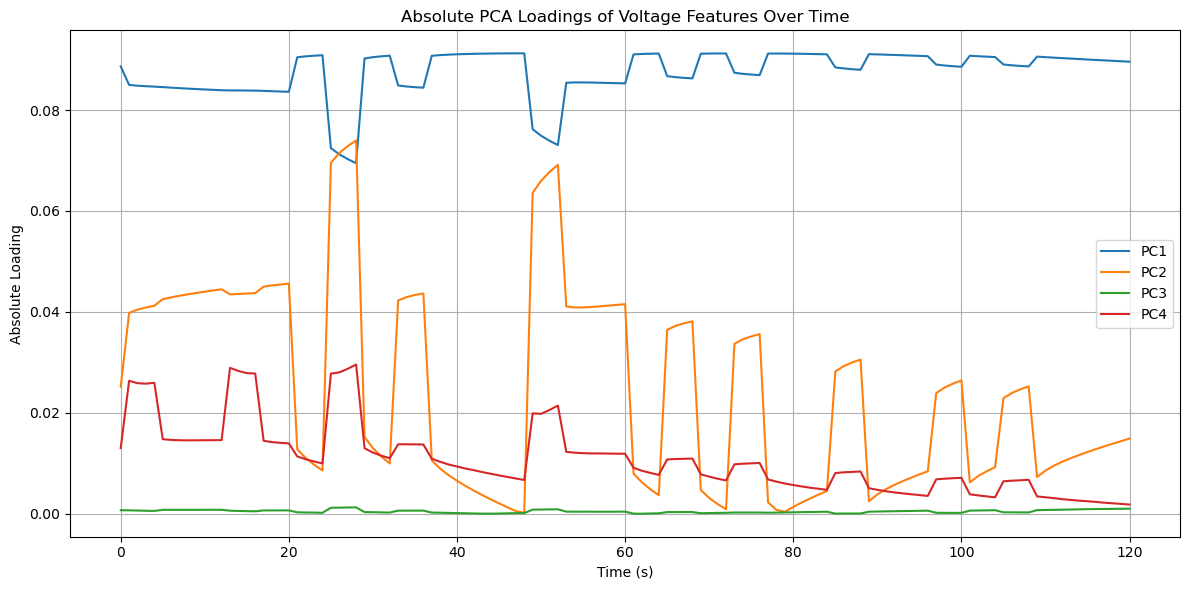

In [87]:
# Here, I wanted to focus on the magnitude of contribution rather than the direction like positive or negative
# so, these absolute loadings over time will show  which time intervals in the voltage are most strongly associated with each principal component

plt.figure(figsize=(12, 6))

for pc in ['PC1', 'PC2', 'PC3', 'PC4']:
    plt.plot(pc_voltage_loadings['time'], pc_voltage_loadings[pc].abs(), label=pc)

plt.title('Absolute PCA Loadings of Voltage Features Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Absolute Loading')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Top 10 features contributing to PC2, PC3, and PC4

In [88]:
#Here, in thsi step I tried to identify the top 10 features that contribute most to PC2, PC3, and PC4, complementing the earlier analysis of PC1.
# Since, the top 10 features contributing PC1 (around 0.091) has very little contribution to PC2, PC3, and PC4 (almost close to zero).

# Use the original column names from numeric_C
loadings = pd.DataFrame(pca.components_.T, index=numeric_C.columns,columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# Get top 10 features for each PC (excluding PC1)
top_features_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
top_features_pc3 = loadings['PC3'].abs().sort_values(ascending=False).head(10)
top_features_pc4 = loadings['PC4'].abs().sort_values(ascending=False).head(10)

# Display them
print("Top 10 features contributing to PC2:")
print(top_features_pc2)

print("\nTop 10 features contributing to PC3:")
print(top_features_pc3)

print("\nTop 10 features contributing to PC4:")
print(top_features_pc4)

Top 10 features contributing to PC2:
current_120.0s    0.112331
current_119.0s    0.112301
current_118.0s    0.112271
current_117.0s    0.112236
current_116.0s    0.112190
current_115.0s    0.112140
current_109.0s    0.112131
current_114.0s    0.112110
current_113.0s    0.112084
current_101.0s    0.112077
Name: PC2, dtype: float64

Top 10 features contributing to PC3:
current_73.0s     0.150957
current_59.0s     0.150937
current_65.0s     0.150932
current_34.0s     0.150916
current_74.0s     0.150910
current_68.0s     0.150902
current_108.0s    0.150897
current_54.0s     0.150878
current_76.0s     0.150836
current_57.0s     0.150827
Name: PC3, dtype: float64

Top 10 features contributing to PC4:
current_15.0s    0.347555
current_14.0s    0.347526
current_3.0s     0.347428
current_2.0s     0.347347
current_16.0s    0.347286
current_4.0s     0.347132
current_13.0s    0.346994
current_1.0s     0.346821
current_25.0s    0.052192
current_28.0s    0.050574
Name: PC4, dtype: float64


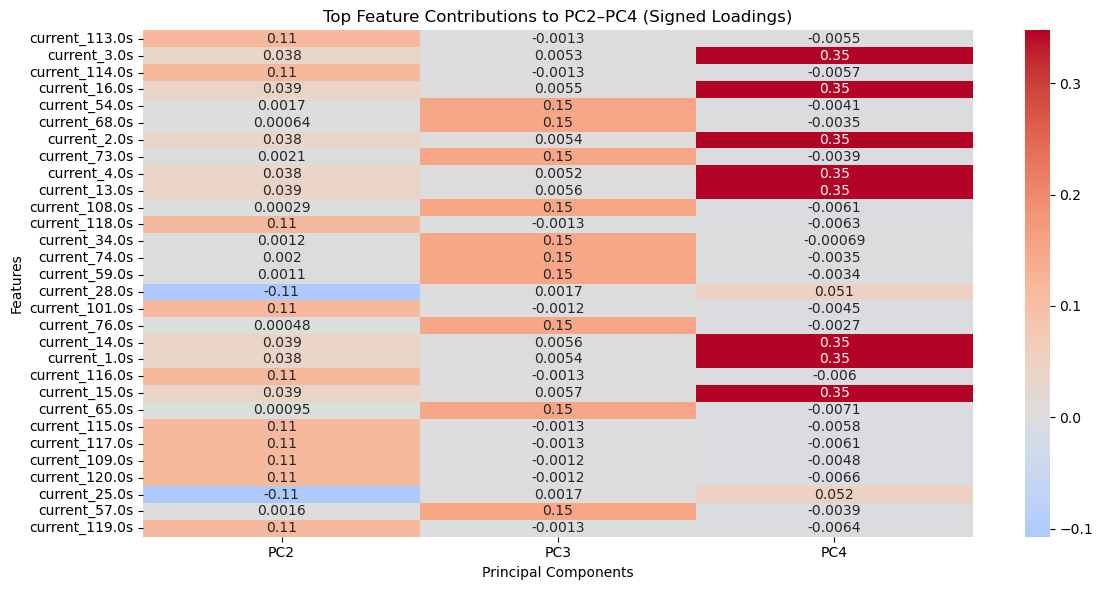

In [89]:

# Getting top 10 features for PC2-PC4
top_features_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10).index
top_features_pc3 = loadings['PC3'].abs().sort_values(ascending=False).head(10).index
top_features_pc4 = loadings['PC4'].abs().sort_values(ascending=False).head(10).index

# 
top_features_combined = list(set(top_features_pc2) | set(top_features_pc3) | set(top_features_pc4))
combined_loadings = loadings.loc[top_features_combined, ['PC2', 'PC3', 'PC4']]

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(combined_loadings, annot=True, cmap='coolwarm', center=0)
plt.title("Top Feature Contributions to PC2–PC4 (Signed Loadings)")
plt.xlabel("Principal Components")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

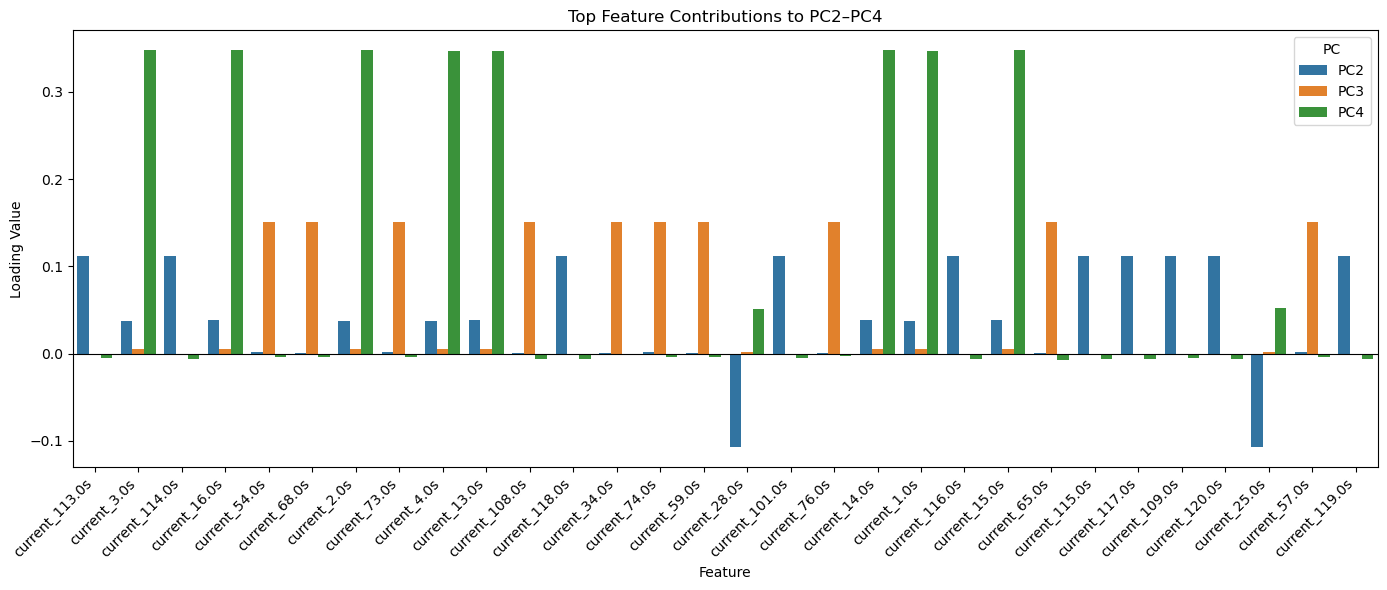

In [90]:
#
melted = combined_loadings.reset_index().melt(id_vars='index', var_name='PC', value_name='Loading')
melted.rename(columns={'index': 'Feature'}, inplace=True)

plt.figure(figsize=(14, 6))
sns.barplot(data=melted, x='Feature', y='Loading', hue='PC')
plt.title("Top Feature Contributions to PC2–PC4")
plt.ylabel("Loading Value")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()